In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Sütun isimleri
cols = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]

# Verileri oku
train_df = pd.read_csv('../data/train_FD001.txt', sep=r'\s+', header=None, names=cols)
test_df = pd.read_csv('../data/test_FD001.txt', sep=r'\s+', header=None, names=cols)
true_rul = pd.read_csv('../data/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

print(f"Eğitim satır sayısı: {len(train_df)}")
print(f"Test satır sayısı: {len(test_df)}")
print(f"Test edilecek motor sayısı: {len(true_rul)}")

# İlk 5 satıra bak
train_df.head()

Eğitim satır sayısı: 20631
Test satır sayısı: 13096
Test edilecek motor sayısı: 100


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Örnek veriler (Modelinden gelen tahminler olduğunu varsayalım)
cycles = np.arange(1, 201)
predicted_rul = np.linspace(190, 0, 200) # 190'dan 0'a azalan RUL

plt.figure(figsize=(12, 6))

# Bölgeleri Arka Plana Boyama (axhspan)
plt.axhspan(50, 200, color='green', alpha=0.2, label='Sağlıklı (Bakım Gerekmez)')
plt.axhspan(25, 50, color='yellow', alpha=0.3, label='Uyarı (Planlama Yap)')
plt.axhspan(0, 25, color='red', alpha=0.2, label='Kritik (Acil Müdahale)')

# Tahmin Çizgisi
plt.plot(cycles, predicted_rul, color='blue', linewidth=2, label='Tahmin Edilen RUL')

# Grafik Detayları
plt.title('Motor Sağlık Durumu ve Karar Destek Grafiği', fontsize=15)
plt.xlabel('Çevrim (Döngü) Sayısı', fontsize=12)
plt.ylabel('Kalan Ömür (RUL)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [7]:
# Her motorun ulaştığı maksimum döngü sayısını hesapla
max_cycle = train_df.groupby('id')['cycle'].max().reset_index()
max_cycle.columns = ['id', 'max_cycle']

# Maksimum döngü bilgisini ana tabloya ekle
train_df = train_df.merge(max_cycle, on=['id'], how='left')

# Kalan Faydalı Ömür (RUL) hesapla
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Artık ihtiyacımız olmayan max_cycle sütununu silelim
train_df.drop('max_cycle', axis=1, inplace=True)

print("RUL sütunu başarıyla eklendi!")
train_df[['id', 'cycle', 'RUL']].head()

RUL sütunu başarıyla eklendi!


,id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


In [8]:
# Standart sapması 0 olan (hiç değişmeyen) sütunları bulalım
stats = train_df.describe().T
constant_cols = stats[stats['std'] == 0].index.tolist()

print(f"Silinecek sabit sütunlar: {constant_cols}")

# Bu sütunları hem eğitim hem test setinden çıkaralım
train_df.drop(constant_cols, axis=1, inplace=True)
test_df.drop(constant_cols, axis=1, inplace=True)

Silinecek sabit sütunlar: ['setting3', 's1', 's10', 's18', 's19']


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Dosyayı güvenli bir şekilde oku ve temizle
with open('train_FD001.txt', 'r') as f:
    # Her satırı oku, sağındaki/solundaki boşlukları sil ve parçala
    lines = [line.strip().split() for line in f.readlines()]

# 2. DataFrame oluştur (Sadece ilk 26 sütunu alıyoruz)
col_names = ['unit_nr', 'time_cycles', 'os_1', 'os_2', 'os_3'] + [f's_{i}' for i in range(1, 22)]
train_df = pd.DataFrame(lines, columns=col_names)

# Sütunları sayısal tipe çevir (Önemli: Veriler metin olarak gelmiş olabilir)
train_df = train_df.apply(pd.to_numeric)

def plot_critical_threshold(df, engine_id):
    # Belirli bir motoru filtrele
    engine_data = df[df['unit_nr'] == engine_id].copy()
    
    # RUL Hesapla
    max_cycle = engine_data['time_cycles'].max()
    engine_data['RUL'] = max_cycle - engine_data['time_cycles']
    
    # Grafik Çizimi
    plt.figure(figsize=(10, 6))
    
    # Arka Plan Bölgeleri
    plt.axhspan(50, engine_data['RUL'].max() + 5, color='green', alpha=0.15, label='Sağlıklı')
    plt.axhspan(25, 50, color='yellow', alpha=0.25, label='Uyarı (Planlama)')
    plt.axhspan(0, 25, color='red', alpha=0.15, label='Kritik (Acil Bakım)')
    
    # RUL Trendi
    plt.plot(engine_data['time_cycles'], engine_data['RUL'], color='darkblue', linewidth=2, label='RUL Azalışı')
    
    plt.title(f'Motor {engine_id} Sağlık Analizi', fontsize=12, fontweight='bold')
    plt.xlabel('Döngü (Cycle)')
    plt.ylabel('Kalan Ömür (RUL)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Test Et
plot_critical_threshold(train_df, engine_id=1)

FileNotFoundError: [Errno 2] No such file or directory: 'train_FD001.txt'

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# id, cycle ve hedef değişkenimiz olan RUL dışındaki sütunları ölçeklendirelim
features = [col for col in train_df.columns if col not in ['id', 'cycle', 'RUL']]

# Ölçeklendirme işlemini uygula
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features]) # Test setine aynı ölçeği uygula

print("Veriler 0-1 aralığına ölçeklendi.")

Veriler 0-1 aralığına ölçeklendi.


In [10]:
# Her motor için son 5 döngünün ortalamasını hesaplayan bir fonksiyon
window_size = 5

for sensor in features:
    # Eğitim seti için hareketli ortalama
    train_df[f'{sensor}_av'] = train_df.groupby('id')[sensor].transform(lambda x: x.rolling(window=window_size).mean())
    # Test seti için hareketli ortalama
    test_df[f'{sensor}_av'] = test_df.groupby('id')[sensor].transform(lambda x: x.rolling(window=window_size).mean())

# Hareketli ortalamadan dolayı oluşan ilk 4 satırdaki boşlukları (NaN) temizleyelim
train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

print("Hareketli ortalama özellikleri eklendi.")

Hareketli ortalama özellikleri eklendi.


In [11]:
from sklearn.model_selection import train_test_split

# Öznitelikleri (X) ve hedef değişkeni (y) belirleyelim
# 'id', 'cycle' ve 'RUL' sütunlarını X'ten çıkarıyoruz
X = train_df.drop(['id', 'cycle', 'RUL'], axis=1)
y = train_df['RUL']

# Verinin %80'ini eğitim, %20'sini test (val) için ayıralım
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Doğrulama seti boyutu: {X_val.shape}")

Eğitim seti boyutu: (16504, 38)
Doğrulama seti boyutu: (4127, 38)


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Modeli tanımla
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Modeli eğit
rf_model.fit(X_train, y_train)

# Doğrulama setinde tahmin yap
y_pred = rf_model.predict(X_val)

# Başarı metriklerini hesapla
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Ortalama Mutlak Hata (MAE): {mae:.2f} döngü")
print(f"R-Kare (Başarı Oranı): %{r2*100:.2f}")

Ortalama Mutlak Hata (MAE): 24.50 döngü
R-Kare (Başarı Oranı): %72.97


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Strateji: RUL Clipping (Üst Sınır Koyma)
# Motor çok sağlıklıyken tahmin yapmaya çalışmak hata payını artırır.
# RUL değerini 125 ile sınırlayalım.
y_train_clipped = y_train.clip(upper=125)
y_val_clipped = y_val.clip(upper=125)

# 2. Strateji: Daha Güçlü Model Parametreleri
# n_estimators: Ağaç sayısı (artırmak genelde iyidir)
# max_features: Her bölünmede bakılacak özellik sayısı (sqrt veya log2)
# min_samples_leaf: Aşırı öğrenmeyi (overfitting) engellemek için
best_rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=15, 
    min_samples_leaf=2, 
    max_features='sqrt',
    random_state=42, 
    n_jobs=-1
)

# Modeli eğit
best_rf.fit(X_train, y_train_clipped)

# Tahmin yap
y_pred_best = best_rf.predict(X_val)

# Başarıyı ölç
new_mae = mean_absolute_error(y_val_clipped, y_pred_best)
new_r2 = r2_score(y_val_clipped, y_pred_best)

print(f"Eski MAE: 24.5")
print(f"Yeni MAE: {new_mae:.2f}")
print(f"Yeni R2 Skoru: %{new_r2*100:.2f}")

Eski MAE: 24.5
Yeni MAE: 11.70
Yeni R2 Skoru: %83.66


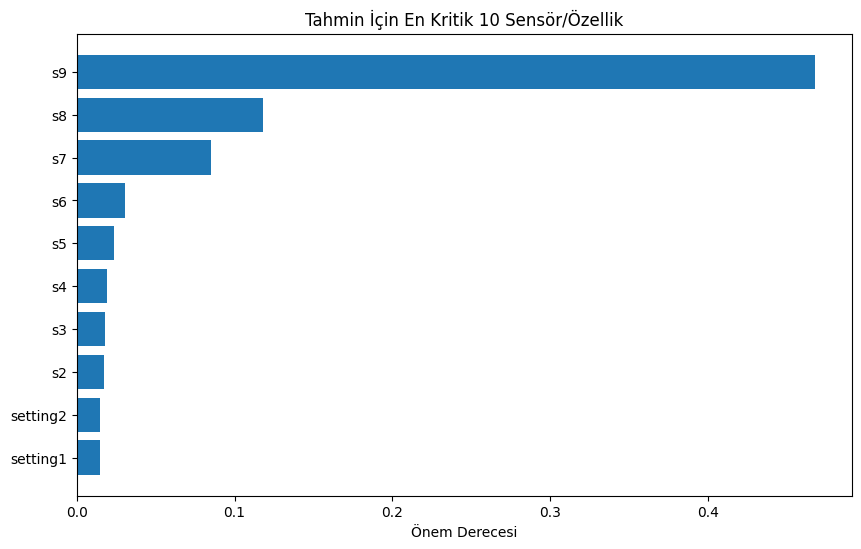

In [14]:
# Özellik önem derecelerini al
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:]  # En önemli 10 özelliği al

plt.figure(figsize=(10, 6))
plt.title('Tahmin İçin En Kritik 10 Sensör/Özellik')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in range(len(indices))])
plt.xlabel('Önem Derecesi')
plt.show()

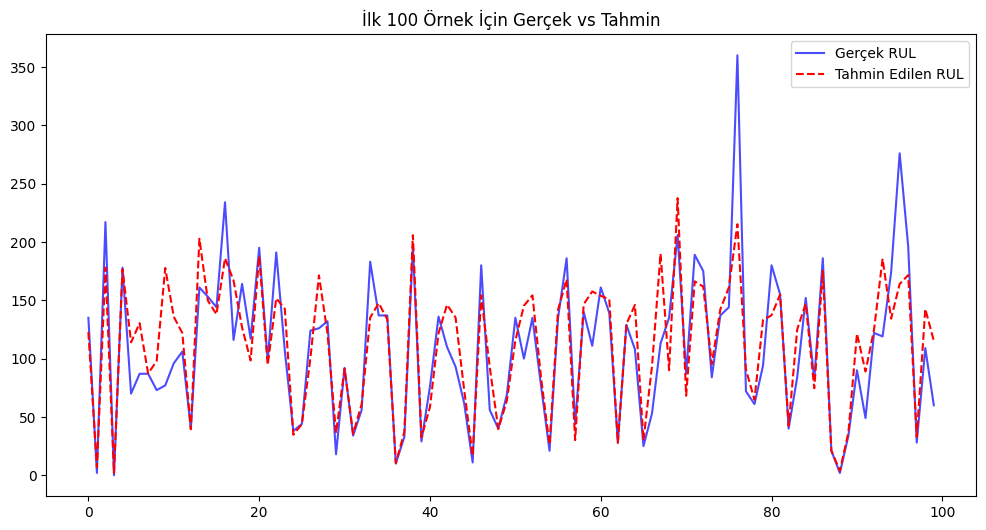

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(y_val.values[:100], label='Gerçek RUL', color='blue', alpha=0.7)
plt.plot(y_pred[:100], label='Tahmin Edilen RUL', color='red', linestyle='--')
plt.title('İlk 100 Örnek İçin Gerçek vs Tahmin')
plt.legend()
plt.show()

--- FİNAL TEST SONUÇLARI ---
Final MAE: 11.92 döngü
Final R2 Skoru: %81.37


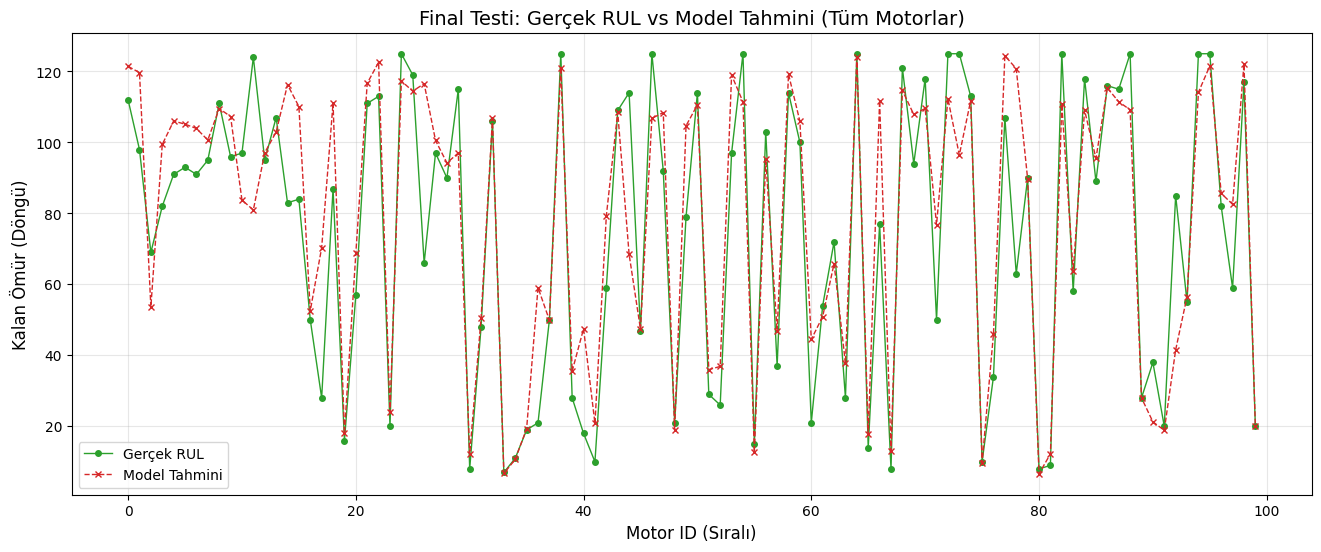

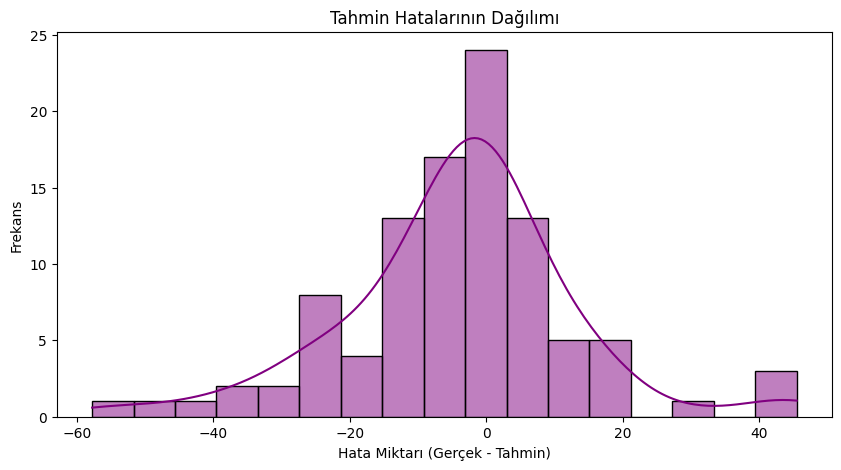

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Test verisindeki her motorun en güncel (son) halini al
X_test_last = test_df.groupby('id').last().reset_index()

# 2. Modelin beklediği sütunları (X_train ile aynı sırada) seç
model_features = X_train.columns.tolist()
X_test_final = X_test_last[model_features]

# 3. Tahmin Yap
y_test_pred = best_rf.predict(X_test_final)

# 4. Gerçek cevaplarla karşılaştır (Clipped versiyon)
y_test_true = true_rul.values.flatten()
y_test_true_clipped = np.clip(y_test_true, 0, 125)

# 5. Başarı Metrikleri
final_mae = mean_absolute_error(y_test_true_clipped, y_test_pred)
final_r2 = r2_score(y_test_true_clipped, y_test_pred)

print(f"--- FİNAL TEST SONUÇLARI ---")
print(f"Final MAE: {final_mae:.2f} döngü")
print(f"Final R2 Skoru: %{final_r2*100:.2f}")

# 6. GÖRSELLEŞTİRME: Gerçek vs Tahmin Grafiği
plt.figure(figsize=(16, 6))

# Gerçek değerler (Yeşil Çizgi)
plt.plot(y_test_true_clipped, label='Gerçek RUL', color='#2ca02c', marker='o', markersize=4, linewidth=1)
# Tahmin değerleri (Kırmızı Kesikli Çizgi)
plt.plot(y_test_pred, label='Model Tahmini', color='#d62728', linestyle='--', marker='x', markersize=4, linewidth=1)

plt.title('Final Testi: Gerçek RUL vs Model Tahmini (Tüm Motorlar)', fontsize=14)
plt.xlabel('Motor ID (Sıralı)', fontsize=12)
plt.ylabel('Kalan Ömür (Döngü)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. GÖRSELLEŞTİRME: Hata Dağılımı (Error Distribution)
errors = y_test_true_clipped - y_test_pred
plt.figure(figsize=(10, 5))
sns.histplot(errors, kde=True, color='purple')
plt.title('Tahmin Hatalarının Dağılımı')
plt.xlabel('Hata Miktarı (Gerçek - Tahmin)')
plt.ylabel('Frekans')
plt.show()